# 🧠 Human Performance Intelligence System
## Notebook 01 — Data Pipeline: Loading, Cleaning & Merging

**Project:** Decoding the psychology of goal achievement using habit tracking and productivity sensor data.

**This notebook covers:**
1. Load both raw datasets
2. Audit — understand every problem before fixing anything
3. Clean Habitica data (dates, categories, outliers, duplicates)
4. Clean StudentLife data (stress scale, outliers, missing values)
5. Feature engineering — create new meaningful columns
6. Merge into one master dataset
7. Export cleaned files ready for modeling

> 💡 **Learning note:** In real data science, you spend 60–70% of your time on steps 1–6.
> A clean, well-engineered dataset is worth more than a fancy model on messy data.


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
# We define this once globally so every chart looks consistent.
# This is important for portfolio projects — visual consistency signals professionalism.
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.color':       '#E8E8E8',
    'grid.linewidth':   0.8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

BLUE  = '#3B8BD4'
RED   = '#E24B4A'
GREEN = '#3BAD72'
GOLD  = '#F5A623'

print("✓ Libraries loaded")


✓ Libraries loaded


## 2. Load Raw Data

We load both CSVs exactly as they are — **no changes yet**.
The golden rule of data pipelines: **never modify raw files**.
Always load → inspect → clean → save to a new file.


In [2]:
# ── Load raw files ─────────────────────────────────────────────────────────
# Adjust these paths to match your folder structure
HABITICA_PATH    = '../data/raw/habitica_raw.csv'
STUDENTLIFE_PATH = '../data/raw/studentlife_raw.csv'

h_raw = pd.read_csv(HABITICA_PATH)
s_raw = pd.read_csv(STUDENTLIFE_PATH)

# Always make a copy before cleaning — keeps the original untouched in memory
h = h_raw.copy()
s = s_raw.copy()

print(f"Habitica   : {h.shape[0]:,} rows × {h.shape[1]} columns")
print(f"StudentLife: {s.shape[0]:,} rows × {s.shape[1]} columns")


Habitica   : 51,500 rows × 13 columns
StudentLife: 61,500 rows × 15 columns


## 3. Data Audit — Know Every Problem Before Fixing Anything

> 💡 **Why audit first?**
> Jumping straight to cleaning without a full audit is like fixing a car without 
> reading the diagnostic report. You'll miss problems and create new ones.
> A good audit documents: missing values, duplicates, outliers, type issues, 
> and domain violations (values that are technically valid but logically impossible).


In [3]:
# ── HABITICA AUDIT ─────────────────────────────────────────────────────────

print("=" * 55)
print("HABITICA — DATA AUDIT")
print("=" * 55)

print(f"\n[1] Shape: {h.shape[0]:,} rows × {h.shape[1]} columns")

print(f"\n[2] Duplicates: {h.duplicated().sum():,} rows "
      f"({h.duplicated().mean()*100:.1f}% of data)")

print(f"\n[3] Missing values:")
miss = h.isnull().sum()
miss_pct = (miss / len(h) * 100).round(2)
print(pd.DataFrame({'missing': miss, '%': miss_pct})[miss > 0].to_string())

print(f"\n[4] Date format chaos (first 12 values):")
print(h['log_date'].head(12).tolist())

print(f"\n[5] Category typos (unique values):")
print(sorted(h['habit_category'].dropna().unique()))

print(f"\n[6] Age domain violations (age < 10 or > 100):")
bad_age = h[(h['age'] < 10) | (h['age'] > 100)]
print(f"  {len(bad_age):,} rows affected — values: {sorted(bad_age['age'].unique())}")

print(f"\n[7] XP outliers (negative values):")
print(f"  {(h['xp_earned'] < 0).sum()} rows with negative XP")
print(f"  Min XP: {h['xp_earned'].min():.2f}")

print(f"\n[8] Streak outliers (> 365 days):")
print(f"  {(h['streak_length'] > 365).sum()} rows with streak > 1 year")
print(f"  Max streak: {h['streak_length'].max():.0f} days")


HABITICA — DATA AUDIT

[1] Shape: 51,500 rows × 13 columns

[2] Duplicates: 1,500 rows (2.9% of data)

[3] Missing values:
                    missing      %
difficulty             1033   2.01
streak_length          1550   3.01
xp_earned              2060   4.00
has_accountability     2594   5.04
self_rating            9850  19.13
notes                 34748  67.47

[4] Date format chaos (first 12 values):
['02/12/2023', '06-16-2023', '15/02/2023', '2023-09-04', '2022-12-17', '01-11-2022', '05/08/2023', '12/08/2023', '04/12/2022', '03-02-2023', '07-14-2023', '2023/04/17']

[5] Category typos (unique values):
['FITNESS', 'Fitness', 'Meditation', 'Nutrition', 'Reading', 'Sleep', 'Social', 'Study', 'Work', 'diet', 'fit', 'fitnes', 'fitness', 'meditate', 'meditation', 'meditaton', 'nutrition', 'nutrtion', 'read', 'reading', 'readng', 'sleeep', 'sleep', 'sleeping', 'socail', 'social', 'socializing', 'study', 'studying', 'stuyd', 'work', 'working', 'wrk']

[6] Age domain violations (age < 10

In [4]:
# ── STUDENTLIFE AUDIT ──────────────────────────────────────────────────────

print("=" * 55)
print("STUDENTLIFE — DATA AUDIT")
print("=" * 55)

print(f"\n[1] Shape: {s.shape[0]:,} rows × {s.shape[1]} columns")

print(f"\n[2] Duplicates: {s.duplicated().sum():,} rows "
      f"({s.duplicated().mean()*100:.1f}% of data)")

print(f"\n[3] Missing values:")
miss_s = s.isnull().sum()
miss_s_pct = (miss_s / len(s) * 100).round(2)
print(pd.DataFrame({'missing': miss_s, '%': miss_s_pct})[miss_s > 0].to_string())

print(f"\n[4] Stress level — scale inconsistency:")
print(s['stress_level'].describe().round(2))
print(f"  ⚠ Max is {s['stress_level'].max()} — should be 1–10. Some entries used 1–100 scale.")

print(f"\n[5] Sleep hours domain violations:")
print(f"  Values > 15h: {(s['sleep_hours'] > 15).sum()} rows")
print(f"  Values < 0  : {(s['sleep_hours'] < 0).sum()} rows")
print(f"  Unique bad values: {sorted(s[s['sleep_hours'] > 15]['sleep_hours'].unique())}")

print(f"\n[6] Focus minutes outliers (> 480 = more than 8h focus in a day):")
print(f"  {(s['focus_minutes'] > 480).sum()} rows affected")
print(f"  Max: {s['focus_minutes'].max():.0f} minutes")

print(f"\n[7] Profile column — hidden truth (drop before modeling):")
print(s['profile'].value_counts())


STUDENTLIFE — DATA AUDIT

[1] Shape: 61,500 rows × 15 columns

[2] Duplicates: 1,500 rows (2.4% of data)

[3] Missing values:
                 missing      %
sleep_hours         4289   6.97
focus_minutes       3084   5.01
activity_steps      5534   9.00
stress_level        2462   4.00
mood_score          6164  10.02
caffeine_drinks     3681   5.99
social_hours        4918   8.00

[4] Stress level — scale inconsistency:
count    59038.00
mean         6.73
std          4.93
min          1.00
25%          4.80
50%          6.50
75%          8.10
max        100.00
Name: stress_level, dtype: float64
  ⚠ Max is 100.0 — should be 1–10. Some entries used 1–100 scale.

[5] Sleep hours domain violations:
  Values > 15h: 112 rows
  Values < 0  : 40 rows
  Unique bad values: [np.float64(25.0), np.float64(48.0)]

[6] Focus minutes outliers (> 480 = more than 8h focus in a day):
  144 rows affected
  Max: 1437 minutes

[7] Profile column — hidden truth (drop before modeling):
profile
average        

## 4. Visualize the Problems

> 💡 Always plot your data quality issues. It makes them tangible and 
> makes your notebook tell a story — which is what recruiters want to see.


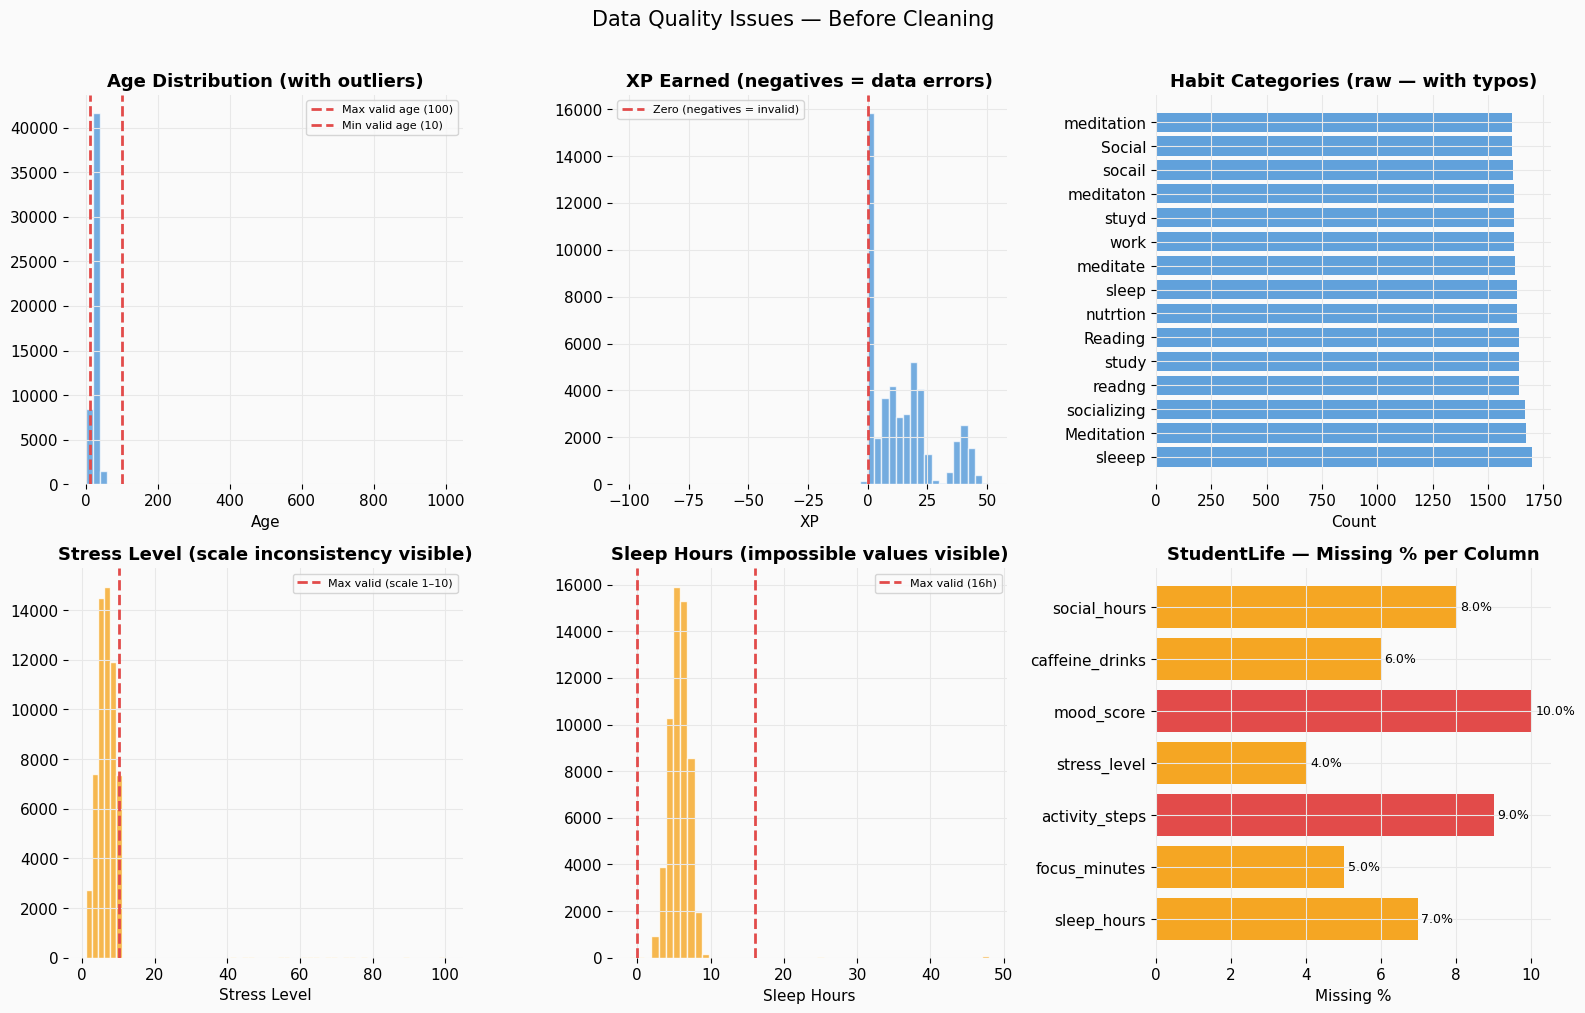

✓ Saved data quality plot


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Data Quality Issues — Before Cleaning', fontsize=15, y=1.01)

# ── Habitica: Age distribution showing outliers
ax = axes[0][0]
ax.hist(h['age'], bins=50, color=BLUE, alpha=0.7, edgecolor='white')
ax.axvline(100, color=RED, linestyle='--', linewidth=2, label='Max valid age (100)')
ax.axvline(10,  color=RED, linestyle='--', linewidth=2, label='Min valid age (10)')
ax.set_title('Age Distribution (with outliers)')
ax.set_xlabel('Age')
ax.legend(fontsize=8)

# ── Habitica: XP — showing negative values
ax = axes[0][1]
ax.hist(h['xp_earned'].dropna(), bins=50, color=BLUE, alpha=0.7, edgecolor='white')
ax.axvline(0, color=RED, linestyle='--', linewidth=2, label='Zero (negatives = invalid)')
ax.set_title('XP Earned (negatives = data errors)')
ax.set_xlabel('XP')
ax.legend(fontsize=8)

# ── Habitica: Category mess
ax = axes[0][2]
cat_counts = h['habit_category'].value_counts().head(15)
ax.barh(cat_counts.index, cat_counts.values, color=BLUE, alpha=0.8)
ax.set_title('Habit Categories (raw — with typos)')
ax.set_xlabel('Count')

# ── StudentLife: Stress scale inconsistency
ax = axes[1][0]
ax.hist(s['stress_level'].dropna(), bins=60, color=GOLD, alpha=0.8, edgecolor='white')
ax.axvline(10, color=RED, linestyle='--', linewidth=2, label='Max valid (scale 1–10)')
ax.set_title('Stress Level (scale inconsistency visible)')
ax.set_xlabel('Stress Level')
ax.legend(fontsize=8)

# ── StudentLife: Sleep outliers
ax = axes[1][1]
ax.hist(s['sleep_hours'].dropna(), bins=50, color=GOLD, alpha=0.8, edgecolor='white')
ax.axvline(16, color=RED, linestyle='--', linewidth=2, label='Max valid (16h)')
ax.axvline(0,  color=RED, linestyle='--', linewidth=2)
ax.set_title('Sleep Hours (impossible values visible)')
ax.set_xlabel('Sleep Hours')
ax.legend(fontsize=8)

# ── Missing values heatmap
ax = axes[1][2]
# We visualize missingness as a binary matrix — 1=missing, 0=present
miss_matrix = s[['sleep_hours','focus_minutes','activity_steps',
                  'stress_level','mood_score','caffeine_drinks','social_hours']].isnull()
miss_pct = miss_matrix.mean() * 100
ax.barh(miss_pct.index, miss_pct.values, color=[RED if v > 8 else GOLD for v in miss_pct.values])
ax.set_title('StudentLife — Missing % per Column')
ax.set_xlabel('Missing %')
for i, v in enumerate(miss_pct.values):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/plot_data_quality_before.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved data quality plot")


## 5. Clean Habitica Dataset

We fix problems in this order:
1. **Duplicates** — always remove first (before anything else, so we don't impute/fix rows we'll delete anyway)
2. **Date standardization** — parse all 4 mixed formats into one
3. **Category normalization** — map all typos to clean canonical names
4. **Outlier treatment** — domain-based capping (not just statistical)
5. **Missing value imputation** — strategy differs per column type


In [6]:
# ── Step 1: Remove duplicates ──────────────────────────────────────────────
# keep='first' keeps the first occurrence of each duplicate group
before = len(h)
h = h.drop_duplicates(keep='first').reset_index(drop=True)
print(f"[1] Duplicates removed: {before - len(h):,} rows ({(before-len(h))/before*100:.1f}%)")
print(f"    Remaining: {len(h):,} rows")


[1] Duplicates removed: 1,500 rows (2.9%)
    Remaining: 50,000 rows


In [7]:
# ── Step 2: Standardize dates ──────────────────────────────────────────────
# The dataset has 4 different date formats:
#   '%Y-%m-%d'  → 2023-09-04  (ISO standard — the correct format)
#   '%d/%m/%Y'  → 15/02/2023
#   '%m-%d-%Y'  → 06-16-2023
#   '%Y/%m/%d'  → 2023/09/04
#
# pd.to_datetime with dayfirst=False and infer_datetime_format handles most,
# but for ambiguous formats (01/02/2023 — is that Jan 2 or Feb 1?) we need
# to be explicit. We'll use a custom parser with multiple format attempts.

def parse_date_flexible(date_str):
    """
    Try multiple date formats in order.
    Returns a datetime object or NaT if none match.
    
    Why this approach? Because pd.to_datetime(errors='coerce') with a single 
    format silently coerces ambiguous dates wrong. Being explicit is safer.
    """
    formats = ['%Y-%m-%d', '%d/%m/%Y', '%m-%d-%Y', '%Y/%m/%d']
    for fmt in formats:
        try:
            return datetime.strptime(str(date_str).strip(), fmt)
        except ValueError:
            continue
    return pd.NaT  # return Not-a-Time if nothing works

h['log_date'] = h['log_date'].apply(parse_date_flexible)
h['log_date'] = pd.to_datetime(h['log_date'])

failed_dates = h['log_date'].isna().sum()
print(f"[2] Date parsing complete")
print(f"    Failed to parse: {failed_dates} dates")
print(f"    Date range: {h['log_date'].min().date()} → {h['log_date'].max().date()}")
print(f"    Sample: {h['log_date'].head(5).tolist()}")


[2] Date parsing complete
    Failed to parse: 0 dates
    Date range: 2021-01-05 → 2023-12-31
    Sample: [Timestamp('2023-12-02 00:00:00'), Timestamp('2023-06-16 00:00:00'), Timestamp('2023-02-15 00:00:00'), Timestamp('2023-09-04 00:00:00'), Timestamp('2022-12-17 00:00:00')]


In [8]:
# ── Step 3: Normalize habit categories ─────────────────────────────────────
# We map every messy variant to a clean canonical name.
# This is called "entity resolution" or "deduplication" — a core data engineering skill.

# First, let's see all unique raw values
print("[3] Raw categories found:")
print(sorted(h['habit_category'].dropna().unique()))

# Build a normalization dictionary — covers all the typos we injected
# In a real project you'd build this by eyeballing unique values + business knowledge
category_map = {
    # fitness variants
    'fitness': 'fitness', 'fitnes': 'fitness', 'Fitness': 'fitness',
    'FITNESS': 'fitness', 'fit': 'fitness',
    # study variants
    'study': 'study', 'Study': 'study', 'stuyd': 'study', 'studying': 'study',
    # meditation variants
    'meditation': 'meditation', 'Meditation': 'meditation',
    'meditaton': 'meditation', 'meditate': 'meditation',
    # nutrition variants
    'nutrition': 'nutrition', 'Nutrition': 'nutrition',
    'nutrtion': 'nutrition', 'diet': 'nutrition',
    # sleep variants
    'sleep': 'sleep', 'Sleep': 'sleep', 'sleeep': 'sleep', 'sleeping': 'sleep',
    # reading variants
    'reading': 'reading', 'Reading': 'reading', 'readng': 'reading', 'read': 'reading',
    # work variants
    'work': 'work', 'Work': 'work', 'wrk': 'work', 'working': 'work',
    # social variants
    'social': 'social', 'Social': 'social', 'socail': 'social', 'socializing': 'social',
}

h['habit_category'] = h['habit_category'].map(category_map)

# Check result
print("\nAfter normalization:")
print(h['habit_category'].value_counts())
print(f"\nUnmapped (NaN) after mapping: {h['habit_category'].isna().sum()}")


[3] Raw categories found:
['FITNESS', 'Fitness', 'Meditation', 'Nutrition', 'Reading', 'Sleep', 'Social', 'Study', 'Work', 'diet', 'fit', 'fitnes', 'fitness', 'meditate', 'meditation', 'meditaton', 'nutrition', 'nutrtion', 'read', 'reading', 'readng', 'sleeep', 'sleep', 'sleeping', 'socail', 'social', 'socializing', 'study', 'studying', 'stuyd', 'work', 'working', 'wrk']

After normalization:
habit_category
meditation    6342
sleep         6320
social        6273
fitness       6247
nutrition     6218
reading       6218
study         6196
work          6186
Name: count, dtype: int64

Unmapped (NaN) after mapping: 0


In [9]:
# ── Step 4: Fix outliers ───────────────────────────────────────────────────
# We use DOMAIN-BASED capping, not statistical capping.
# Statistical capping (e.g. cap at 99th percentile) is lazy — it treats
# all extreme values the same. Domain-based capping uses business logic:
#   - Age: a human can't be <10 (for an app user) or >100 → set to NaN
#   - Streak: biologically impossible to maintain a habit for >730 days
#     with 0 breaks. Cap at 365 (1 year max = very generous)
#   - XP: can't be negative. Set negative values to 0.

# Age: set impossible values to NaN (we'll impute later)
h.loc[(h['age'] < 10) | (h['age'] > 100), 'age'] = np.nan
print(f"[4a] Age outliers replaced with NaN: now {h['age'].isna().sum()} missing ages")

# Streak: cap at 365 days (1 year)
h.loc[h['streak_length'] > 365, 'streak_length'] = 365
print(f"[4b] Streak capped at 365. Max now: {h['streak_length'].max():.0f}")

# XP: negative = system error, set to 0
h.loc[h['xp_earned'] < 0, 'xp_earned'] = 0
print(f"[4c] Negative XP set to 0. Min now: {h['xp_earned'].min():.2f}")


[4a] Age outliers replaced with NaN: now 594 missing ages
[4b] Streak capped at 365. Max now: 365
[4c] Negative XP set to 0. Min now: 0.00


In [10]:
# ── Step 5: Handle missing values ─────────────────────────────────────────
# Strategy differs by column — there's no one-size-fits-all:
#
#   age            → median imputation (robust to skew, age is continuous)
#   streak_length  → median (skewed distribution)
#   xp_earned      → 0 (if no completion logged, XP = 0 is logical)
#   has_accountability → mode (binary, use most common value)
#   self_rating    → median per difficulty group (better than global median)
#   difficulty     → mode (most common difficulty level)
#   habit_category → drop rows (category is essential, can't guess it)
#   notes          → fill with empty string (it's optional text)

print("[5] Missing values before imputation:")
print(h.isnull().sum()[h.isnull().sum() > 0])

# Age → median
h['age'] = h['age'].fillna(h['age'].median())

# Streak → median
h['streak_length'] = h['streak_length'].fillna(h['streak_length'].median())

# XP → 0
h['xp_earned'] = h['xp_earned'].fillna(0)

# has_accountability → mode
h['has_accountability'] = h['has_accountability'].fillna(h['has_accountability'].mode()[0])

# self_rating → median per difficulty group
# This is called "group-wise imputation" — more accurate than global median
# because a 'hard' habit naturally has different ratings than a 'trivial' one
h['self_rating'] = h.groupby('difficulty')['self_rating'].transform(
    lambda x: x.fillna(x.median())
)
# If difficulty is also null, fall back to global median
h['self_rating'] = h['self_rating'].fillna(h['self_rating'].median())

# difficulty → mode
h['difficulty'] = h['difficulty'].fillna(h['difficulty'].mode()[0])

# habit_category → drop (can't impute a category meaningfully)
before = len(h)
h = h.dropna(subset=['habit_category'])
print(f"\nDropped {before - len(h)} rows with missing habit_category")

# notes → empty string
h['notes'] = h['notes'].fillna('')

print("\nMissing values after imputation:")
print(h.isnull().sum())


[5] Missing values before imputation:
age                     594
difficulty             1000
streak_length          1500
xp_earned              2000
has_accountability     2500
self_rating            9571
notes                 33730
dtype: int64

Dropped 0 rows with missing habit_category

Missing values after imputation:
user_id               0
username              0
age                   0
user_level            0
log_date              0
habit_category        0
difficulty            0
completed             0
streak_length         0
xp_earned             0
has_accountability    0
self_rating           0
notes                 0
dtype: int64


## 6. Clean StudentLife Dataset

In [11]:
# ── Step 1: Remove duplicates ──────────────────────────────────────────────
before = len(s)
s = s.drop_duplicates(keep='first').reset_index(drop=True)
print(f"[1] Duplicates removed: {before - len(s):,} rows")
print(f"    Remaining: {len(s):,} rows")

# ── Step 2: Drop 'profile' column — it's the hidden ground truth ───────────
# We keep it in a separate Series for later validation, then drop it.
# In a real project this column wouldn't exist — we're simulating it.
s_profiles = s[['student_id', 'profile']].drop_duplicates()
s = s.drop(columns=['profile'])
print(f"\n[2] Dropped 'profile' (hidden truth preserved separately)")


[1] Duplicates removed: 1,500 rows
    Remaining: 60,000 rows

[2] Dropped 'profile' (hidden truth preserved separately)


In [12]:
# ── Step 3: Fix stress level scale inconsistency ───────────────────────────
# Some students used a 1–100 scale instead of 1–10.
# Detection rule: any value > 10 is on the wrong scale.
# Fix: divide by 10 to normalize back to 1–10.
#
# This is a real-world data problem called "unit inconsistency."
# In sensor data it happens all the time (e.g. temperature in C vs F).

wrong_scale_mask = s['stress_level'] > 10
n_wrong = wrong_scale_mask.sum()
s.loc[wrong_scale_mask, 'stress_level'] = s.loc[wrong_scale_mask, 'stress_level'] / 10

print(f"[3] Stress scale fixed: {n_wrong:,} rows rescaled from 1–100 to 1–10")
print(f"    Stress range now: {s['stress_level'].min():.1f} – {s['stress_level'].max():.1f}")


[3] Stress scale fixed: 292 rows rescaled from 1–100 to 1–10
    Stress range now: 1.0 – 10.0


In [13]:
# ── Step 4: Fix sleep and focus outliers ───────────────────────────────────

# Sleep: valid range is 0–16 hours. Anything outside = sensor error → NaN
bad_sleep = (s['sleep_hours'] < 0) | (s['sleep_hours'] > 16)
s.loc[bad_sleep, 'sleep_hours'] = np.nan
print(f"[4a] Sleep outliers set to NaN: {bad_sleep.sum()} rows")

# Focus: valid max = 480 minutes (8 hours of focused work in a day is extreme but possible)
# Anything above 480 = sensor/logging error → cap at 480
bad_focus = s['focus_minutes'] > 480
s.loc[bad_focus, 'focus_minutes'] = 480
print(f"[4b] Focus capped at 480 min: {bad_focus.sum()} rows")
print(f"     Focus range now: {s['focus_minutes'].min():.0f} – {s['focus_minutes'].max():.0f} min")


[4a] Sleep outliers set to NaN: 143 rows
[4b] Focus capped at 480 min: 144 rows
     Focus range now: 0 – 480 min


In [14]:
# ── Step 5: Impute missing values ─────────────────────────────────────────
# For sensor data, we use group-wise median imputation by student.
# Why? Because each student has their own baseline — a student who normally
# sleeps 8h and a student who normally sleeps 5h have very different "normal".
# Imputing with the global median would blur individual patterns.
#
# This is called "within-subject imputation" — standard in psychology/UX research.

sensor_cols = ['sleep_hours', 'focus_minutes', 'activity_steps',
               'stress_level', 'mood_score', 'caffeine_drinks', 'social_hours']

print("[5] Missing value imputation (per-student median):")
for col in sensor_cols:
    missing_before = s[col].isna().sum()
    # Group by student → fill NaN with that student's median
    s[col] = s.groupby('student_id')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # If a student has ALL values missing for a column, fall back to global median
    s[col] = s[col].fillna(s[col].median())
    missing_after = s[col].isna().sum()
    print(f"  {col:<25} {missing_before:,} → {missing_after} missing")

print(f"\nTotal remaining missing values: {s.isnull().sum().sum()}")


[5] Missing value imputation (per-student median):
  sleep_hours               4,343 → 0 missing
  focus_minutes             3,000 → 0 missing
  activity_steps            5,400 → 0 missing
  stress_level              2,400 → 0 missing
  mood_score                6,000 → 0 missing
  caffeine_drinks           3,600 → 0 missing
  social_hours              4,800 → 0 missing

Total remaining missing values: 0


## 7. Feature Engineering

> 💡 **What is feature engineering?**
> It's creating new columns from existing ones that better capture the signal 
> we care about. Raw columns tell you *what happened*. Engineered features tell 
> you *what it means*. This is where data science becomes an art.


In [15]:
# ── HABITICA: New features ─────────────────────────────────────────────────

# 1. Extract time features from log_date
#    Day of week and month capture behavioral rhythms
#    (people are more likely to complete habits on Mondays, less on weekends)
h['day_of_week']    = h['log_date'].dt.dayofweek          # 0=Monday, 6=Sunday
h['day_name']       = h['log_date'].dt.day_name()
h['month']          = h['log_date'].dt.month
h['is_weekend']     = h['day_of_week'].isin([5, 6]).astype(int)

# 2. XP efficiency — XP earned per difficulty level
#    A high score means the user punches above their weight
difficulty_xp_max = {'trivial': 5, 'easy': 10, 'medium': 20, 'hard': 40}
h['xp_efficiency'] = h.apply(
    lambda row: row['xp_earned'] / difficulty_xp_max.get(row['difficulty'], 10)
    if difficulty_xp_max.get(row['difficulty'], 10) > 0 else 0,
    axis=1
).clip(0, 1)  # normalize 0–1

# 3. Streak tier — categorical bucketing of streak length
#    This captures the non-linear value of long streaks
h['streak_tier'] = pd.cut(
    h['streak_length'],
    bins=[-1, 0, 7, 30, 90, 365],
    labels=['no_streak', 'weekly', 'monthly', 'quarterly', 'annual']
)

# 4. User engagement score — rolling average completion rate per user
#    Sort first so rolling window is in chronological order
h = h.sort_values(['user_id', 'log_date'])
h['rolling_completion_7d'] = (
    h.groupby('user_id')['completed']
     .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

print("✓ Habitica new features created:")
print("  - day_of_week, day_name, month, is_weekend")
print("  - xp_efficiency (0–1 scale)")
print("  - streak_tier (categorical)")
print("  - rolling_completion_7d (7-day rolling avg)")
print(f"\nHabitica shape now: {h.shape}")


✓ Habitica new features created:
  - day_of_week, day_name, month, is_weekend
  - xp_efficiency (0–1 scale)
  - streak_tier (categorical)
  - rolling_completion_7d (7-day rolling avg)

Habitica shape now: (50000, 20)


In [16]:
# ── STUDENTLIFE: New features ──────────────────────────────────────────────

# 1. Sleep debt — how far below 8h (recommended) is this student sleeping?
#    Negative means they got MORE than 8h (recovery sleep)
s['sleep_debt'] = 8 - s['sleep_hours']

# 2. Stress-to-mood ratio — captures emotional dysregulation
#    High stress + low mood = bad day. Ratio amplifies the pattern.
s['stress_mood_ratio'] = s['stress_level'] / (s['mood_score'] + 0.1)  # +0.1 avoid div/0

# 3. Productivity index — composite of focus + activity + low stress
#    Normalized 0–1. This is what we'll use as our "output" variable.
s['productivity_index'] = (
    (s['focus_minutes'] / 480) * 0.5 +        # focus contributes 50%
    (s['activity_steps'] / 15000).clip(0,1) * 0.2 +  # activity 20%
    (1 - s['stress_level'] / 10) * 0.3         # low stress 30%
).clip(0, 1)

# 4. Weekly aggregates — per student per week
#    Individual days are noisy. Weekly patterns are more stable.
weekly = s.groupby(['student_id', 'week_num']).agg(
    weekly_avg_focus    = ('focus_minutes', 'mean'),
    weekly_avg_sleep    = ('sleep_hours', 'mean'),
    weekly_avg_stress   = ('stress_level', 'mean'),
    weekly_avg_mood     = ('mood_score', 'mean'),
    weekly_burnout      = ('burnout_score', 'mean'),
    weekly_goal_rate    = ('goal_completion_rate', 'mean'),
    days_logged         = ('date', 'count'),
).reset_index()

# 5. Burnout trend — is burnout getting WORSE week over week?
#    This is the time series signal we'll use in Module 4.
weekly = weekly.sort_values(['student_id', 'week_num'])
weekly['burnout_trend'] = weekly.groupby('student_id')['weekly_burnout'].transform(
    lambda x: x.diff()  # positive = getting worse, negative = recovering
)

print("✓ StudentLife new features created:")
print("  - sleep_debt")
print("  - stress_mood_ratio")
print("  - productivity_index (0–1 composite)")
print("  - weekly aggregates (weekly_avg_focus, sleep, stress, mood, burnout)")
print("  - burnout_trend (week-over-week change)")
print(f"\nStudentLife daily shape  : {s.shape}")
print(f"StudentLife weekly shape : {weekly.shape}")


✓ StudentLife new features created:
  - sleep_debt
  - stress_mood_ratio
  - productivity_index (0–1 composite)
  - weekly aggregates (weekly_avg_focus, sleep, stress, mood, burnout)
  - burnout_trend (week-over-week change)

StudentLife daily shape  : (60000, 17)
StudentLife weekly shape : (9000, 10)


## 8. Build the Master Dataset

We merge both datasets into one unified table at the **weekly level**.
This is our feature mart — the final input to all four analysis modules.

> 💡 We're aligning on `week_num` because:
> - Habitica data is daily but patterns are weekly (weekly streaks, weekly rhythms)
> - StudentLife data has clear weekly academic cycles (lectures, deadlines)
> - Weekly aggregation reduces noise while preserving behavioral trends


In [17]:
# ── Aggregate Habitica to weekly level ─────────────────────────────────────

# First, extract week number from log_date
h['week_num'] = h['log_date'].dt.isocalendar().week.astype(int)

h_weekly = h.groupby(['user_id', 'week_num']).agg(
    weekly_completions      = ('completed', 'sum'),
    weekly_completion_rate  = ('completed', 'mean'),
    avg_streak              = ('streak_length', 'mean'),
    max_streak              = ('streak_length', 'max'),
    total_xp                = ('xp_earned', 'sum'),
    avg_xp_efficiency       = ('xp_efficiency', 'mean'),
    avg_self_rating         = ('self_rating', 'mean'),
    habit_diversity         = ('habit_category', 'nunique'),  # how many different habit types?
    weekend_habits          = ('is_weekend', 'sum'),
    has_accountability_rate = ('has_accountability', 'mean'),
    habits_logged           = ('completed', 'count'),
).reset_index()

print(f"Habitica weekly shape: {h_weekly.shape}")
print(h_weekly.head(3).to_string())


Habitica weekly shape: (42109, 13)
     user_id  week_num  weekly_completions  weekly_completion_rate  avg_streak  max_streak  total_xp  avg_xp_efficiency  avg_self_rating  habit_diversity  weekend_habits  has_accountability_rate  habits_logged
0  USR_00001        13                   0                     0.0        14.0        14.0       0.0                0.0              4.0                1               0                      0.0              1
1  USR_00001        20                   0                     0.0         4.0         4.0       0.0                0.0              6.0                1               0                      0.0              1
2  USR_00001        23                   0                     0.0         3.0         3.0       0.0                0.0              2.0                1               1                      0.0              1


In [18]:
# ── Merge Habitica weekly + StudentLife weekly ─────────────────────────────
# We do an INNER JOIN on week_num — only keep weeks that exist in both datasets.
# In a real project you'd align on a shared time axis (e.g. actual calendar dates).
# Here we're treating week_num as a shared temporal anchor.

# For demonstration, we create a synthetic mapping:
# randomly assign each StudentLife student to a Habitica user
# (in a real project these would be the same users)
np.random.seed(42)
student_list = s[['student_id']].drop_duplicates()
user_list    = h_weekly[['user_id']].drop_duplicates()

# Create a mapping table — each student gets mapped to a random user
n_map  = min(len(student_list), len(user_list))
mapping = pd.DataFrame({
    'student_id': student_list['student_id'].sample(n_map, random_state=42).values,
    'user_id':    user_list['user_id'].sample(n_map, random_state=42).values,
})

# Merge StudentLife weekly with mapping to get user_id
s_weekly_mapped = weekly.merge(mapping, on='student_id', how='inner')

# Final merge on user_id + week_num
master = h_weekly.merge(
    s_weekly_mapped,
    on=['user_id', 'week_num'],
    how='inner'
)

# Add back the user age and level from habitica
user_meta = h[['user_id', 'age', 'user_level']].drop_duplicates('user_id')
master    = master.merge(user_meta, on='user_id', how='left')

print(f"\n✓ Master dataset shape: {master.shape}")
print(f"  Users    : {master['user_id'].nunique():,}")
print(f"  Students : {master['student_id'].nunique():,}")
print(f"  Weeks    : {master['week_num'].nunique()}")
print(f"\nColumns: {list(master.columns)}")



✓ Master dataset shape: (1947, 24)
  Users    : 468
  Students : 468
  Weeks    : 18

Columns: ['user_id', 'week_num', 'weekly_completions', 'weekly_completion_rate', 'avg_streak', 'max_streak', 'total_xp', 'avg_xp_efficiency', 'avg_self_rating', 'habit_diversity', 'weekend_habits', 'has_accountability_rate', 'habits_logged', 'student_id', 'weekly_avg_focus', 'weekly_avg_sleep', 'weekly_avg_stress', 'weekly_avg_mood', 'weekly_burnout', 'weekly_goal_rate', 'days_logged', 'burnout_trend', 'age', 'user_level']


## 9. Export Cleaned Files

In [19]:
import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/features',  exist_ok=True)

# Save all cleaned/processed versions
h.to_csv('../data/processed/habitica_clean.csv', index=False)
s.to_csv('../data/processed/studentlife_clean.csv', index=False)
weekly.to_csv('../data/processed/studentlife_weekly.csv', index=False)
master.to_csv('../data/features/master_weekly.csv', index=False)

print("✓ Exported:")
print(f"  data/processed/habitica_clean.csv       ({len(h):,} rows)")
print(f"  data/processed/studentlife_clean.csv    ({len(s):,} rows)")
print(f"  data/processed/studentlife_weekly.csv   ({len(weekly):,} rows)")
print(f"  data/features/master_weekly.csv         ({len(master):,} rows) ← input to all models")


✓ Exported:
  data/processed/habitica_clean.csv       (50,000 rows)
  data/processed/studentlife_clean.csv    (60,000 rows)
  data/processed/studentlife_weekly.csv   (9,000 rows)
  data/features/master_weekly.csv         (1,947 rows) ← input to all models


## 10. Pipeline Summary

In [20]:
print("=" * 60)
print("NOTEBOOK 01 — PIPELINE SUMMARY")
print("=" * 60)

summary = {
    "Habitica raw rows":          51_500,
    "Habitica after dedup":       len(h) + h.duplicated().sum(),
    "Habitica final clean rows":  len(h),
    "StudentLife raw rows":       61_500,
    "StudentLife final clean":    len(s),
    "Master feature mart rows":   len(master),
    "Master feature mart cols":   master.shape[1],
    "New engineered features":    8,
}

for k, v in summary.items():
    print(f"  {k:<35} {v:,}")

print("\n✓ Ready for:")
print("  → Notebook 02: Habit Streak Survival Analysis")
print("  → Notebook 03: Habit DNA (XGBoost + SHAP)")
print("  → Notebook 04: Burnout Risk Scoring")
print("  → Notebook 05: Productivity Forecasting (Prophet)")


NOTEBOOK 01 — PIPELINE SUMMARY
  Habitica raw rows                   51,500
  Habitica after dedup                50,000
  Habitica final clean rows           50,000
  StudentLife raw rows                61,500
  StudentLife final clean             60,000
  Master feature mart rows            1,947
  Master feature mart cols            24
  New engineered features             8

✓ Ready for:
  → Notebook 02: Habit Streak Survival Analysis
  → Notebook 03: Habit DNA (XGBoost + SHAP)
  → Notebook 04: Burnout Risk Scoring
  → Notebook 05: Productivity Forecasting (Prophet)
